<a href="https://colab.research.google.com/github/linedhurdle/linedhurdle/blob/main/Finance_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

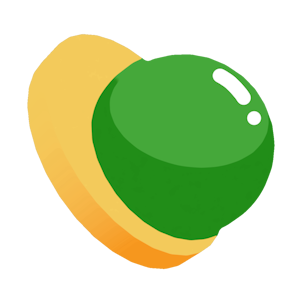

Welcome to the Coinsphere AI Machine Learning Model!

This MLM uses the Yahoo Finance API and the Keras AI open-source library to predict trends in the stock market and help you invest in stocks!

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

In [ ]:
# Fetch Amazon stock data
symbol = "AMZN"
data = yf.download(symbol, start="2020-01-01", end="2025-01-01")
data.reset_index(inplace=True)

[*********************100%***********************]  1 of 1 completed


In [ ]:
#Prepare data
# Convert dates to numerical values
data["DateNumeric"] = (data["Date"] - data["Date"].min()).dt.days
X = data[["DateNumeric"]]
y = data["Close"]


In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Linear Regression Model




In [ ]:
# Train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [ ]:
# Make predictions
y_pred = model.predict(X_test)

In [ ]:
# Predict future prices
days_future = 30  # Predict next 30 days
future_dates = np.array([(data["DateNumeric"].max() + i) for i in range(1, days_future + 1)]).reshape(-1, 1)
future_predictions = model.predict(future_dates)


In [ ]:
# Plot results
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', label='Training Data')
plt.scatter(X_test, y_test, color='red', label='Test Data')
plt.plot(X_test, y_pred, color='green', label='Predicted')
plt.plot(future_dates, future_predictions, color='orange', linestyle='dashed', label='Future Predictions')
plt.xlabel("Days Since Start")
plt.ylabel("Stock Price (USD)")
plt.title("Amazon Stock Price Prediction")
plt.legend()
plt.show()


NameError: name 'plt' is not defined

In [ ]:
# Additional visualizations using Keras
sns.set(style="darkgrid")

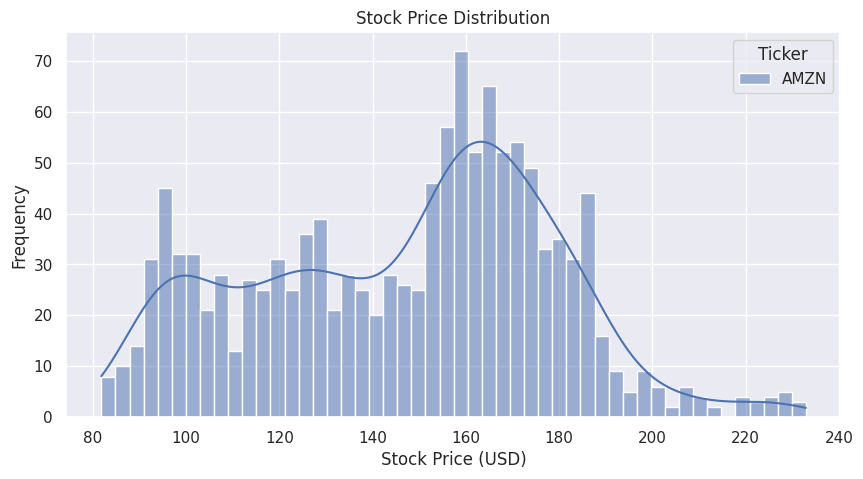

In [ ]:
# Distribution plot of stock prices
plt.figure(figsize=(10, 5))
sns.histplot(y, bins=50, kde=True, color='purple')
plt.title("Stock Price Distribution")
plt.xlabel("Stock Price (USD)")
plt.ylabel("Frequency")
plt.show()


#Keras Model

In [ ]:
# Create and train a simple Keras model
keras_model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(1,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
keras_model.compile(optimizer='adam', loss='mse')
keras_model.fit(X_train, y_train, epochs=500, verbose=0, validation_data=(X_test, y_test))

In [ ]:
# Predictions using Keras model
y_pred_keras = keras_model.predict(X_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


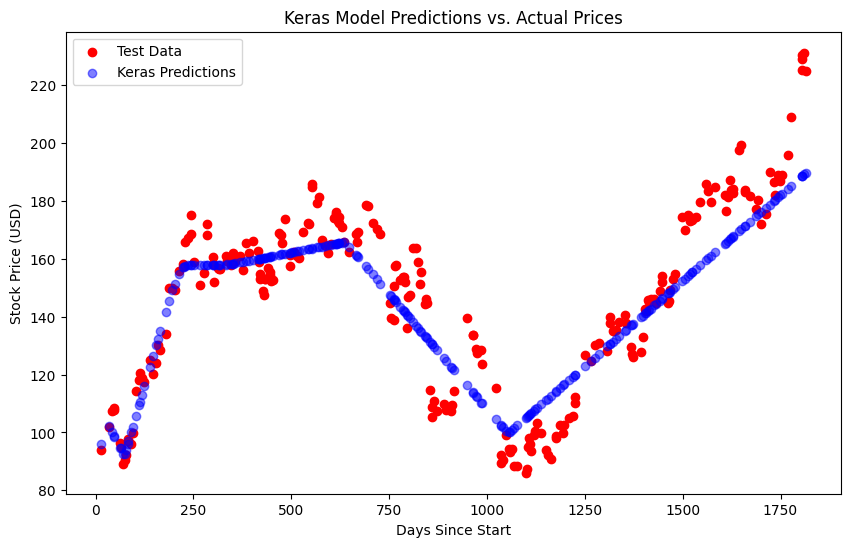

In [ ]:
# Scatter plot for Keras predictions
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='red', label='Test Data')
plt.scatter(X_test, y_pred_keras, color='blue', alpha=0.5, label='Keras Predictions')
plt.xlabel("Days Since Start")
plt.ylabel("Stock Price (USD)")
plt.title("Keras Model Predictions vs. Actual Prices")
plt.legend()
plt.show()

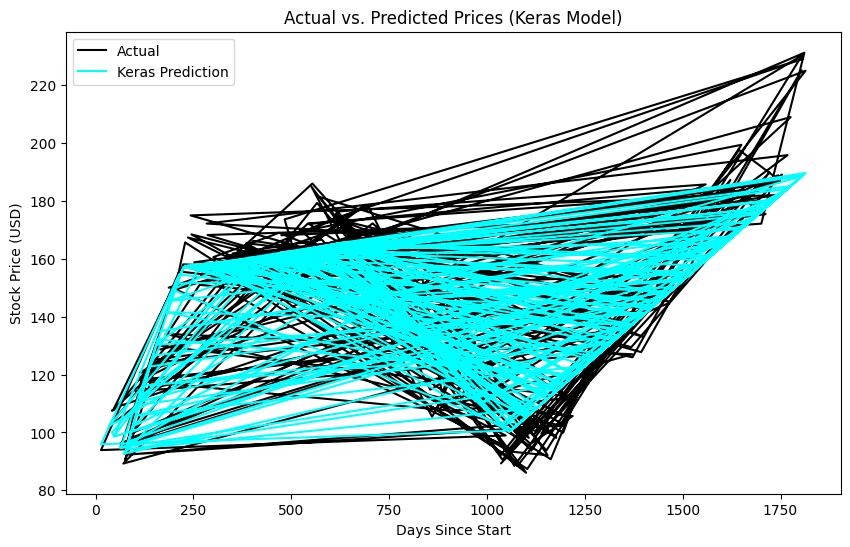

In [ ]:
# Line plot of actual vs. predicted prices
plt.figure(figsize=(10, 6))
plt.plot(X_test, y_test, label='Actual', color='black')
plt.plot(X_test, y_pred_keras, label='Keras Prediction', color='cyan')
plt.xlabel("Days Since Start")
plt.ylabel("Stock Price (USD)")
plt.title("Actual vs. Predicted Prices (Keras Model)")
plt.legend()
plt.show()


#LSTM Model


In [ ]:
# Prepare data for LSTM
sequence_length = 10  # Use last 10 days to predict the next day
train_generator = TimeseriesGenerator(y_train.values, y_train.values, length=sequence_length, batch_size=1)
test_generator = TimeseriesGenerator(y_test.values, y_test.values, length=sequence_length, batch_size=1)

In [ ]:
# Define LSTM model
lstm_model = keras.Sequential([
    layers.LSTM(50, activation='relu', input_shape=(sequence_length, 1)),
    layers.Dense(1)
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(train_generator, epochs=50, verbose=0, validation_data=test_generator)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


In [ ]:
# Predictions using LSTM model
lstm_predictions = lstm_model.predict(test_generator)

242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


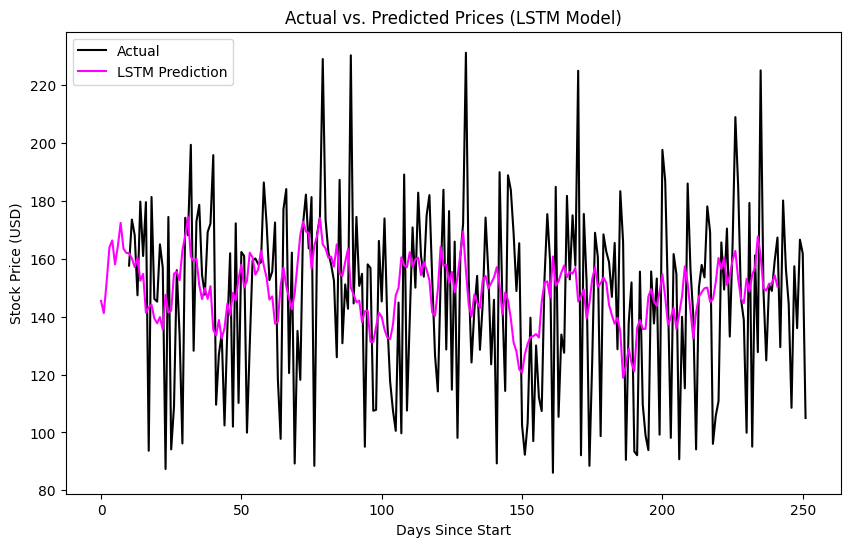

In [ ]:
# Line plot of actual vs. predicted prices (LSTM)
plt.figure(figsize=(10, 6))
plt.plot(range(len(y_test))[sequence_length:], y_test.values[sequence_length:], label='Actual', color='black')
plt.plot(range(len(lstm_predictions)), lstm_predictions, label='LSTM Prediction', color='magenta')
plt.xlabel("Days Since Start")
plt.ylabel("Stock Price (USD)")
plt.title("Actual vs. Predicted Prices (LSTM Model)")
plt.legend()
plt.show()

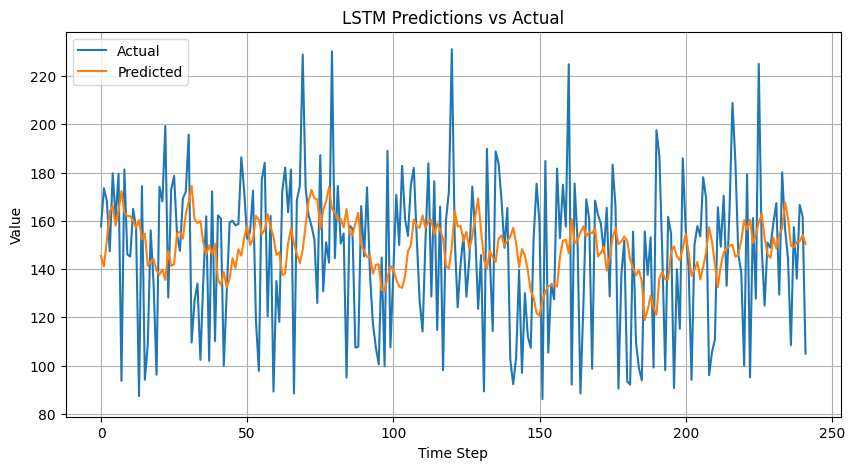

In [ ]:
# Actual values after the sequence offset
actual = y_test.values[sequence_length:]

# Plot predicted vs actual
plt.figure(figsize=(10, 5))
plt.plot(actual, label='Actual')
plt.plot(lstm_predictions, label='Predicted')
plt.title('LSTM Predictions vs Actual')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

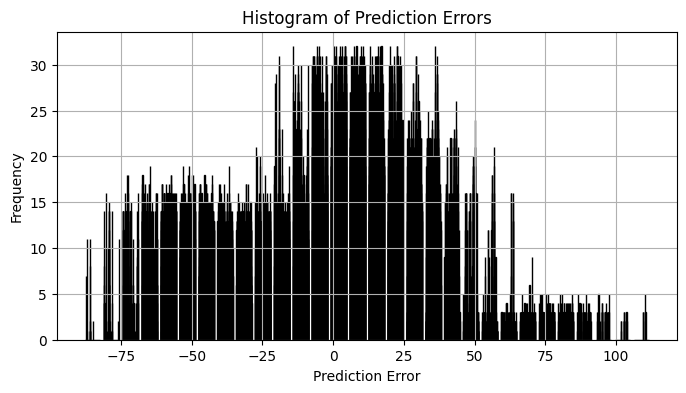

In [ ]:
residuals = actual - lstm_predictions.flatten()
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=30, edgecolor='black')
plt.title('Histogram of Prediction Errors')
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

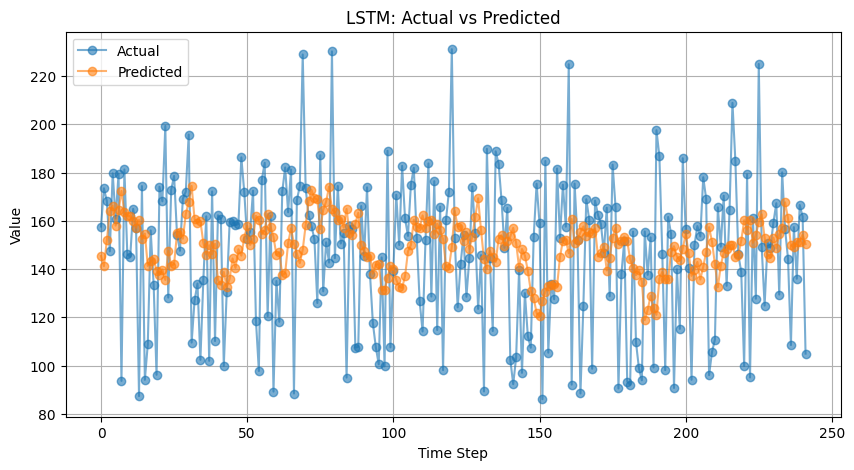

In [ ]:
# Actual values (offset for sequence length)
actual = y_test.values[sequence_length:]

# Flatten predictions
preds = lstm_predictions.flatten()

# Dot plot with line
plt.figure(figsize=(10, 5))
plt.plot(actual, 'o-', label='Actual', alpha=0.6)
plt.plot(preds, 'o-', label='Predicted', alpha=0.6)
plt.title('LSTM: Actual vs Predicted')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

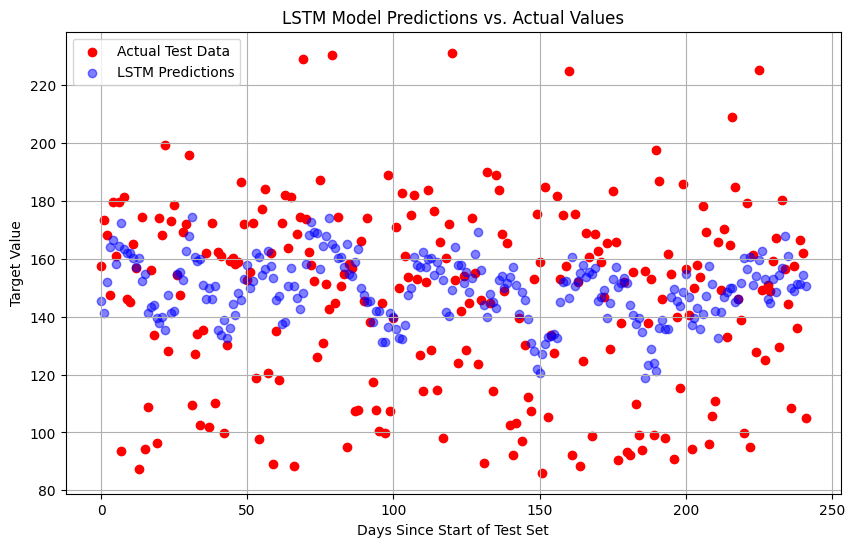

In [ ]:
# Generate x-axis: number of days since test set start (aligned with predictions)
days = np.arange(len(lstm_predictions))

# Adjust actual y values to align with predictions
actual = y_test.values[sequence_length:]
preds = lstm_predictions.flatten()

# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(days, actual, color='red', label='Actual Test Data')
plt.scatter(days, preds, color='blue', alpha=0.5, label='LSTM Predictions')
plt.xlabel("Days Since Start of Test Set")
plt.ylabel("Target Value")
plt.title("LSTM Model Predictions vs. Actual Values")
plt.legend()
plt.grid(True)
plt.show()